In [6]:
import pandas as pd
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
from imblearn.over_sampling import SMOTE

def get_whole_df() -> pd.DataFrame:
    files = glob("combined_part_*.csv")
    df_list = []
    for file in files:
        df_list.append(pd.read_csv(file))

    return pd.concat(df_list, ignore_index=True)

df = get_whole_df()
# print(df.info())
# print("Null: "+str(df.isnull().sum()))
# print(df.columns.values)
# print(df[[" Flow Packets/s", "Flow Bytes/s"]].describe())



In [7]:
# strip whitespace from the headers first
df.columns = df.columns.str.strip()
# print(df.columns.values)

# print("Rows:", len(df))
# print("Duplicate rows:", df.duplicated().sum())
data = df.drop_duplicates()
# print(data["Label"].value_counts())

# Replace infinities with a finite number (e.g. 0 or the column mean)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# # drop minor class:
df = df[df["Label"] != "Heartbleed"]

In [8]:
X = df.drop("Label", axis=1)
y = df["Label"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [9]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train_res, y_train_res)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     87936
   DoS GoldenEye       0.99      1.00      0.99      2059
        DoS Hulk       1.00      1.00      1.00     46025
DoS Slowhttptest       0.99      0.99      0.99      1100
   DoS slowloris       0.99      0.99      0.99      1159

        accuracy                           1.00    138279
       macro avg       0.99      1.00      0.99    138279
    weighted avg       1.00      1.00      1.00    138279



Label
DoS Hulk            351747
BENIGN              351747
DoS GoldenEye       351747
DoS Slowhttptest    351747
DoS slowloris       351747
Name: count, dtype: int64


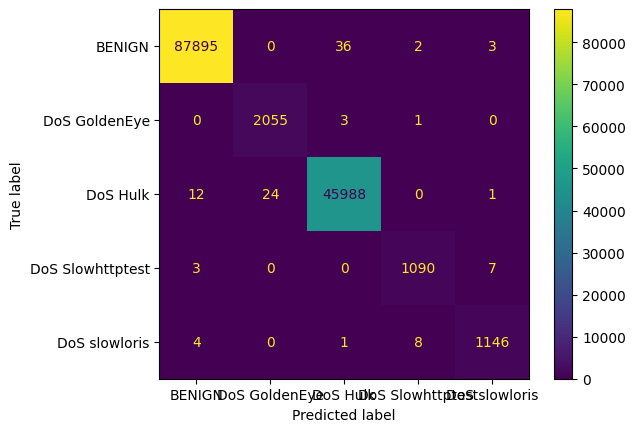

In [10]:
print(pd.Series(y_train_res).value_counts())
ConfusionMatrixDisplay.from_predictions(y_test, pred)